In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("train_house_prices.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
df.head(8)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000


In [4]:
# Após uma análise em toda a base essas são as colunas a serem removidas!

# Dropando colunas por redundância
# Foi feita uma soma de '1stFlrSF', '2ndFlrSF' e 'LowQualFinSF', o total é igual a GrLivArea, logo podemos dropar.
col_rmv_redundancia = ['GarageArea', 'GarageCond', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF']
df.drop(columns=col_rmv_redundancia, inplace=True)

# Dropando colunas por pouca variabilidade
col_rmv_homogenia = ['Utilities', 'Street', 'Condition2', 'Heating', 'KitchenAbvGr']
df.drop(columns=col_rmv_homogenia, inplace=True)

# Dropando colunas por ausência de dados
col_rmv_ausentes = ['Alley', 'MiscFeature', 'MiscVal', 'LotFrontage']
df.drop(columns=col_rmv_ausentes, inplace=True)

In [5]:
# Substituindo todos valores ausentes por 0
# Tratamento de Garagem e Alvenaria
df['GarageType'] = df['GarageType'].fillna("NoGarage")
cols_garagem_alvenaria = ['GarageFinish', 'GarageQual', 'GarageYrBlt', 'PavedDrive', 'MasVnrArea']
df[cols_garagem_alvenaria] = df[cols_garagem_alvenaria].fillna(0)

# Tratamento de Lareira e Cerca
df['FireplaceQu'] = df['FireplaceQu'].fillna(0)
df['Fence'] = df['Fence'].fillna(0)

# FALTANDO: Tratamento do Porão (Essencial para o mapeamento não falhar)
cols_porao = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
df[cols_porao] = df[cols_porao].fillna(0)

# FALTANDO: Tratamento da Elétrica (Único nulo do dataset)
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# FALTANDO: Áreas Externas (Garante que a soma posterior funcione)
cols_ext = ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'WoodDeckSF']
df[cols_ext] = df[cols_ext].fillna(0)

In [6]:
# Mapeamento 


mapQual = {np.nan: 0, 0: 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

mapGarageFinish = {0:0, 'Unf': 0, 'RFn': 1, 'Fin': 2}

mapPavedDrive = {0: 0, 'N': 0, 'P': 1, 'Y': 2}

mapQualBasement = {np.nan: 0, 0: 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}

mapBsmtFinType = {np.nan: 0, 0:0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}

neighborhood_map = {
    'MeadowV': 1, 'IDOTRR': 1, 'BrDale': 1, 'OldTown': 1,
    'Edwards': 2, 'BrkSide': 2, 'Sawyer': 2, 'Blueste': 2, 'SWISU': 2, 'NAmes': 2, 'NPkVill': 2, 'Mitchel': 2,
    'SawyerW': 3, 'Gilbert': 3, 'NWAmes': 3, 'Blmngtn': 3, 'CollgCr': 3, 'ClearCr': 3, 'Crawfor': 3,
    'Veenker': 4, 'Somerst': 4, 'Timber': 4,
    'StoneBr': 5, 'NoRidge': 5, 'NridgHt': 5
}

# Mapeamento por potencial de valorização do terreno
map_lot_config = {
    'CulDSac': 3,   # Máxima privacidade (Rua sem saída)
    'Inside': 1,    # Padrão (Meio de quadra)
    'Corner': 2,    # Esquina
    'FR2': 2,       # Frente para 2 ruas (Similar à esquina)
    'FR3': 2        # Frente para 3 ruas (Similar à esquina)
}

# Criando um mapeamento para classificar os andares das casas
map_subclass = {
    20: 1, 30: 1, 40: 1, 120: 1,
    80: 2, 85: 2, 90: 2,
    60: 3, 70: 3, 75: 3, 160: 3, 180: 3, 190: 3, 45: 2, 50: 2
}

# Fizemos a classificação baseado no preço
map_mszoning = {'C (all)': 1, 'RM': 2, 'RH': 3, 'RL': 4, 'FV': 5}

# Criando um mapa para os valores em Fence
map_fence = {0: 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}

map_foundation = {
    'PConc': 3,
    'Wood': 2, 'CBlock': 2,
    'Stone': 1, 'BrkTil': 1, 'Slab': 1
}

# Mapeando os valores de BldgType
map_BldgType = {
    '1Fam': 2, 'TwnhsE': 2,
    'Duplex': 1, 'Twnhs': 1, '2fmCon': 1
}

# Mapeando os valores de MoSold
map_mosold = {
    5: 3, 6: 3, 7: 3,
    3: 2, 4: 2, 8: 2, 9: 2, 10: 2,
    11: 1, 12: 1, 1: 1, 2: 1
}

# Mapeando os valores de Condition1
map_condition1 = {
    'PosA': 3, 'PosN': 3, 'RRNn': 3, 'RRNe': 3,
    'Norm': 2, 'RRAe': 2, 'RRAn': 2,
    'Artery': 1, 'Feedr': 1
}

# No caso de RoofStyle, temos dois valores importantes Gable e Hip, assim como valores de menor repetência.
map_roofstyle = {
    'Shed': 1, 'Mansard': 1, 'Gambrel': 1, 'Flat': 1, 
    'Gable': 2, 
    'Hip': 3
}

# Mapeando CentralAir (Y/N -> 1/0)
df['CentralAir'] = df['CentralAir'].map({'Y': 1, 'N': 0})

df['GarageQual'] = df['GarageQual'].map(mapQual)
df['HeatingQC'] = df['HeatingQC'].map(mapQual)
df['KitchenQual'] = df['KitchenQual'].map(mapQual)
df['ExterQual'] = df['ExterQual'].map(mapQual)
df['ExterCond'] = df['ExterCond'].map(mapQual)
df['FireplaceQu'] = df['FireplaceQu'].map(mapQual)
df['BsmtQual'] = df['BsmtQual'].map(mapQual)
df['BsmtCond'] = df['BsmtCond'].map(mapQual)

df['GarageFinish'] = df['GarageFinish'].map(mapGarageFinish)

df['PavedDrive'] = df['PavedDrive'].map(mapPavedDrive)

df['BsmtExposure'] = df['BsmtExposure'].map(mapQualBasement)

df['BsmtFinType1'] = df['BsmtFinType1'].map(mapBsmtFinType)
df['BsmtFinType2'] = df['BsmtFinType2'].map(mapBsmtFinType)

df['Neighborhood'] = df['Neighborhood'].map(neighborhood_map)

df['LotConfig'] = df['LotConfig'].map(map_lot_config)

df['MSSubClass'] = df['MSSubClass'].map(map_subclass)

df['MSZoning'] = df['MSZoning'].map(map_mszoning)

df['Foundation'] = df['Foundation'].map(map_foundation)

df['Fence'] = df['Fence'].map(map_fence)

df['BldgType'] = df['BldgType'].map(map_BldgType)

df['MoSold'] = df['MoSold'].map(map_mosold)

df['Condition1'] = df['Condition1'].map(map_condition1)

df['RoofStyle'] = df['RoofStyle'].map(map_roofstyle)

In [7]:
# Colunas que serão transformadas em binárias
# Nesses cenários temos uma forte repetição de uma valor em específico e por isso transformamos a coluna para referenciar esse valor.

df['HasCoveredPorch'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'] > 0).astype(int)
df['IsLotRegular'] = (df['LotShape'] == 'Reg').astype(int)
df['IsLandLevel'] = (df['LandContour'] == 'Lvl').astype(int)
df['IsLandSlopeGentle'] = (df['LandSlope'] == 'Gtl').astype(int)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['Exterior_Mix'] = (df['Exterior1st'] != df['Exterior2nd']).astype(int)
df['Functional'] = (df['Functional'] == 'Typ').astype(int)
df['RoofMatl'] = (df['RoofMatl'] == 'CompShg').astype(int)
df['IsNewProperty'] = (df['SaleCondition'] == 'Partial').astype(int)
df['IsAbnormalSale'] = (df['SaleCondition'] == 'Abnorml').astype(int)
df['Electrical'] = (df['Electrical'] == 'SBrkr').astype(int)


In [8]:
# Nessa célula faremos os tratamentos que envolvem operações matemáticas

# Criando total de banheiros
df['TotalBathrooms'] = df['BsmtFullBath'] + df['FullBath']
# Criando total de Lavabos
df['TotalWashrooms'] = df['BsmtHalfBath'] + df['HalfBath']

# Verificamos que não existem problemas com os valores presentes nas colunas dos anos
# Agora vamos criar uma coluna que vai conter o tempo de vida que a casa possui
df['lifetime'] = df['YrSold'] - df['YearBuilt']

# Criando uma coluna com o tempo da reforma
df['reform'] = df['YrSold'] - df['YearRemodAdd']

df['FireplaceScore'] = df['Fireplaces'] * df['FireplaceQu']

df['BsmtFinSFTotal'] = (df['BsmtFinType1'] + df['BsmtFinType2']) / 2
df['TotalFinBsmtSF'] = df['BsmtFinSF1'] + df['BsmtFinSF2']

# Faremos o somatório de todas as áreas
df['TotalOutdoorSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF']

In [9]:
# Trabalhando com One-Hot Encoding
# Casas sem garagem
df['NoGarage'] = df['GarageType'].apply(lambda x: 1 if x == "NoGarage" else 0)
# Casas com garagem na estrutura principal
df['StructuredGarage'] = df['GarageType'].apply(lambda x: 1 if x in ["Attchd", "BuiltIn", "Basment", "2Types"] else 0)
# Casas com garagem na estrutura externa
df['SeparateGarage'] = df['GarageType'].apply(lambda x: 1 if x in ["Detchd", "CarPort", "2Types"] else 0)


# Definindo os valores mais frequentes
top_materials = ['VinylSd', 'HdBoard', 'MetalSd', 'Wd Sdng', 'Plywood']

# Todos demais valores se tornarão Others
df['Exterior1st'] = df['Exterior1st'].apply(lambda x: x if x in top_materials else 'Other')

In [10]:
# Lista de colunas que foram transformadas e podem ser retiradas
colunas_para_remover = [
    'GarageType', 'BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 
    'BsmtFinSF1', 'BsmtFinSF2', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 
    'ScreenPorch', 'WoodDeckSF', 'YearBuilt', 'YearRemodAdd', 'PoolArea', 
    'PoolQC', 'Exterior2nd', 'LotShape', 'LandContour', 'LandSlope', 
    'FireplaceQu', 'Fireplaces', 'MasVnrType', 'RoofStyle', 'HouseStyle', 
    'SaleCondition', 'SaleType', 'BsmtFinType1', 'BsmtFinType2'
]

df.drop(columns=colunas_para_remover, inplace=True, errors='ignore')

In [11]:
df_final = pd.get_dummies(df, columns=['Neighborhood', 'Exterior1st'])

In [12]:
y = df_final['SalePrice']
X = df_final.drop(columns=['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando o modelo
modelo = RandomForestRegressor(n_estimators=100, random_state=42)

# Treinando (o 'fit' é onde o aprendizado acontece)
modelo.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# Fazendo as previsões com os dados de teste
previsoes = modelo.predict(X_test)

# Calculando o Erro Médio Absoluto (MAE)
erro = mean_absolute_error(y_test, previsoes)

print(f"Sucesso! O modelo foi treinado.")
print(f"Erro Médio Absoluto (MAE): ${erro:,.2f}")

Sucesso! O modelo foi treinado.
Erro Médio Absoluto (MAE): $17,866.73


In [14]:
# Calculando o R² (Coeficiente de Determinação)
r2 = r2_score(y_test, previsoes)

# Calculando a Precisão Média (1 - Erro Percentual Médio)

mape = np.mean(np.abs((y_test - previsoes) / y_test))
acuracia_media = (1 - mape) * 100

print(f"R² (Poder de explicação): {r2:.2%}")
print(f"Acurácia Média Baseada no Erro: {acuracia_media:.2f}%")

R² (Poder de explicação): 88.50%
Acurácia Média Baseada no Erro: 89.21%


In [15]:
# Salvando um modelo do resultado alcançado
joblib.dump(modelo, 'modelo_casas_ames.pkl')
print("Modelo salvo com sucesso!")

# ---------------------------------------------------------
# Como usar no futuro (em outro notebook ou script):
# modelo_carregado = joblib.load('modelo_casas_ames.pkl')
# resultado = modelo_carregado.predict(novos_dados)

Modelo salvo com sucesso!


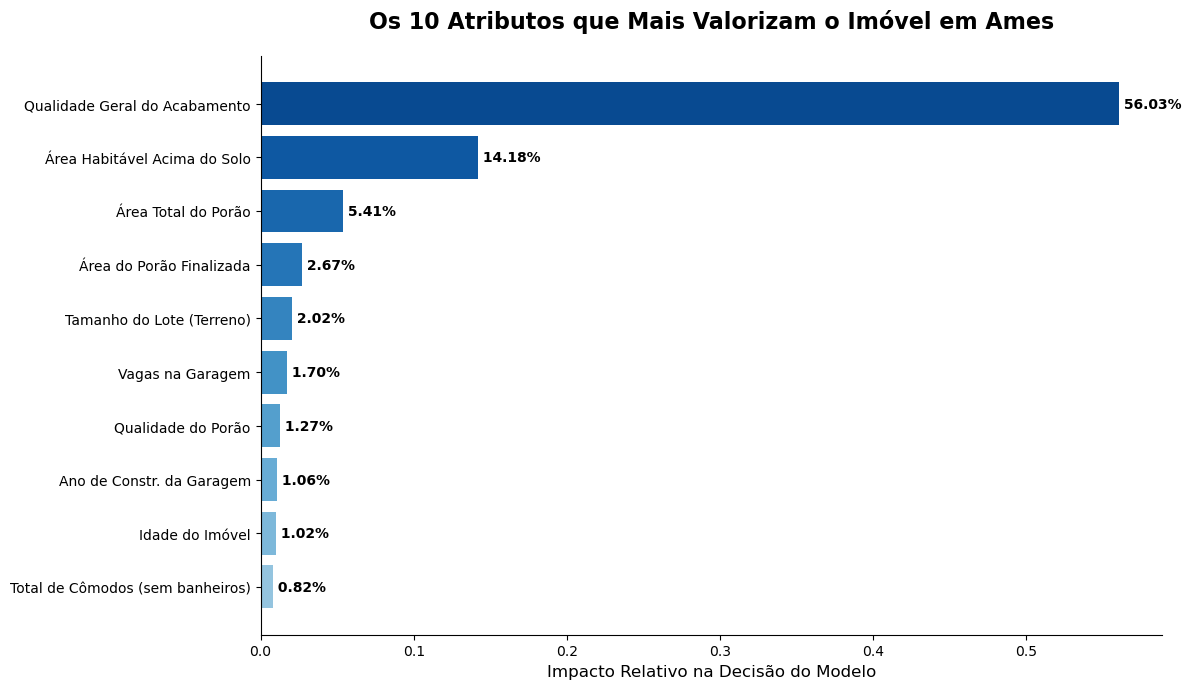

In [16]:
# Dando nomes às colunas para melhor visualização
col_nomes = {
    'OverallQual': 'Qualidade Geral do Acabamento',
    'GrLivArea': 'Área Habitável Acima do Solo',
    'TotalBsmtSF': 'Área Total do Porão',
    'TotalFinBsmtSF': 'Área do Porão Finalizada',
    'LotArea': 'Tamanho do Lote (Terreno)',
    'GarageCars': 'Vagas na Garagem',
    'BsmtQual': 'Qualidade do Porão',
    'GarageYrBlt': 'Ano de Constr. da Garagem',
    'lifetime': 'Idade do Imóvel',
    'TotRmsAbvGrd': 'Total de Cômodos (sem banheiros)'
}

# Preparando os dados
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
top_10 = importancias.nlargest(10).sort_values(ascending=True)


nomes_ajustados = [col_nomes.get(col, col) for col in top_10.index]

# Plotagem
plt.figure(figsize=(12, 7))
cores = plt.cm.Blues(np.linspace(0.4, 0.9, 10)) 

plt.barh(nomes_ajustados, top_10.values, color=cores)


for index, value in enumerate(top_10.values):
    plt.text(value, index, f' {value:.2%}', va='center', fontsize=10, fontweight='bold')

plt.title('Os 10 Atributos que Mais Valorizam o Imóvel em Ames', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Impacto Relativo na Decisão do Modelo', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

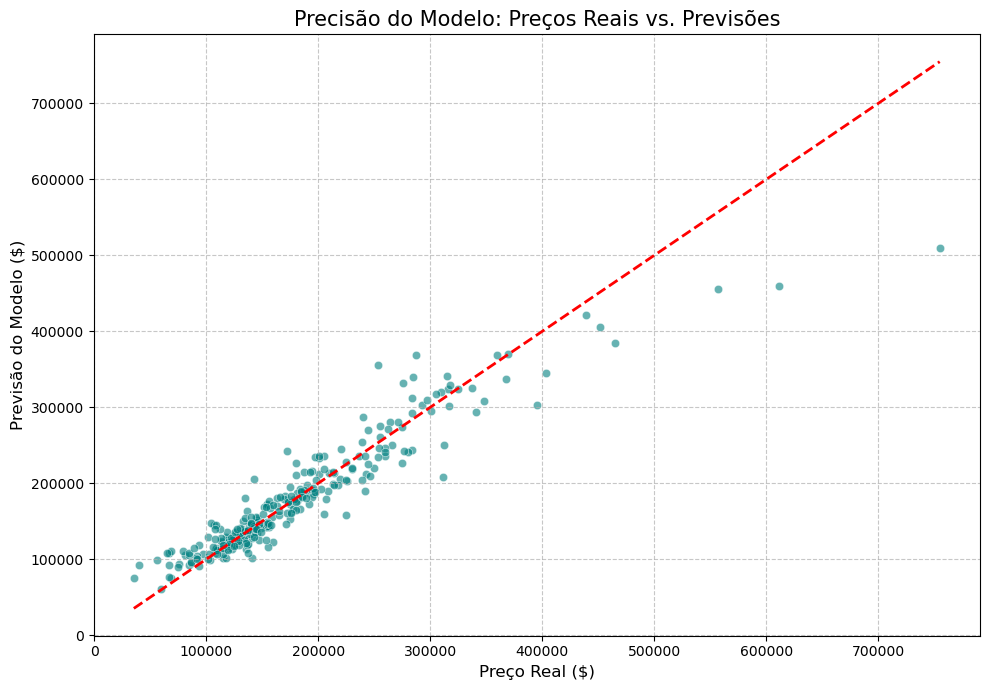

In [17]:
# Configurando a área para o gráfico
fig, ax = plt.subplots(figsize=(10, 7))

# Inserindo valores
sns.scatterplot(x=y_test, y=previsoes, ax=ax, alpha=0.6, color='teal')

# Adicionando a linha de referência
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)


ax.set_title('Precisão do Modelo: Preços Reais vs. Previsões', fontsize=15)
ax.set_xlabel('Preço Real ($)', fontsize=12)
ax.set_ylabel('Previsão do Modelo ($)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

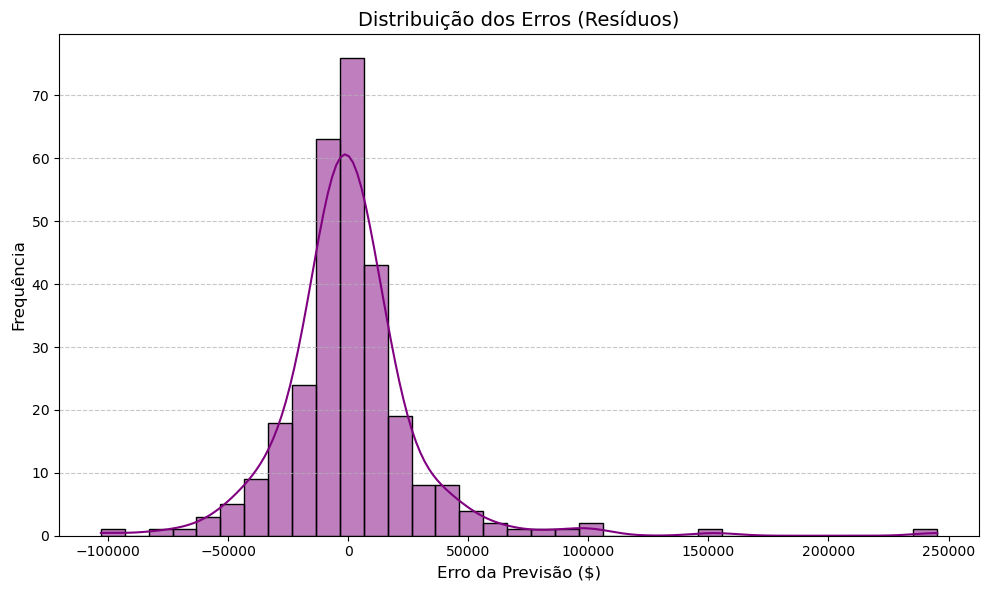

In [18]:
# Calculando os resíduos (Preço Real - Previsão)
residuos = y_test - previsoes

# Configurando o tamanho da figura
plt.figure(figsize=(10, 6))

# Criando o Histograma com a linha de densidade (kde=True)
sns.histplot(residuos, kde=True, color='purple')

# Customização de títulos e eixos
plt.title('Distribuição dos Erros (Resíduos)', fontsize=14)
plt.xlabel('Erro da Previsão ($)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

# Adicionando uma grade melhor visualização do gráfico
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()